# Flight Ticket Price Prediction using Machine Learning Regression

![flight Image]( flightjpeg.jpeg)


### Objective
* Perform data cleaning and preprocessing
* Handle categorical and numerical features
* Apply regression algorithms
* Evaluate model performance
*Compare different machine learning models
* Predict flight ticket prices accurately

## Step 1: Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Regression Algorithms
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor

import warnings
warnings.filterwarnings('ignore')

## Step 2: Load Dataset

In [3]:
# Load dataset
file_path = 'flight_ticket.csv'
df = pd.read_csv(file_path)

# Display first 5 rows
print(df.head())

       Airline     Source Destination                  Route  Journey_Day  \
0       IndiGo  Bangalore   New Delhi              BLR → DEL           24   
1    Air India    Kolkata   Bangalore  CCU → IXR → BBI → BLR            1   
2  Jet Airways      Delhi      Cochin  DEL → LKO → BOM → COK            9   
3       IndiGo    Kolkata   Bangalore        CCU → NAG → BLR           12   
4       IndiGo  Bangalore   New Delhi        BLR → NAG → DEL            1   

   Journey_Month  Journey _Year Journey_Weekday  Dep_Hour  Dep_Minute  \
0              3           2019          Sunday        22          20   
1              5           2019       Wednesday         5          50   
2              6           2019          Sunday         9          25   
3              5           2019          Sunday        18           5   
4              3           2019          Friday        16          50   

   Arr_Hour  Arr_Minute  Duration_Mins Total_Stops Additional_Info  Price  
0         1          1

## Step 3: Basic Exploration

In [4]:
print(df.shape)
print(df.columns)
print(df.info())
print(df.describe())

(10682, 16)
Index(['Airline', 'Source', 'Destination', 'Route', 'Journey_Day',
       'Journey_Month', 'Journey _Year', 'Journey_Weekday', 'Dep_Hour',
       'Dep_Minute', 'Arr_Hour', 'Arr_Minute', 'Duration_Mins', 'Total_Stops',
       'Additional_Info', 'Price'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10682 entries, 0 to 10681
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10682 non-null  object
 1   Source           10682 non-null  object
 2   Destination      10682 non-null  object
 3   Route            10682 non-null  object
 4   Journey_Day      10682 non-null  int64 
 5   Journey_Month    10682 non-null  int64 
 6   Journey _Year    10682 non-null  int64 
 7   Journey_Weekday  10682 non-null  object
 8   Dep_Hour         10682 non-null  int64 
 9   Dep_Minute       10682 non-null  int64 
 10  Arr_Hour         10682 non-null  int64 
 11  Arr_Minute   

## Step 4: Check Missing Values

In [5]:
print(df.isnull().sum())

Airline            0
Source             0
Destination        0
Route              0
Journey_Day        0
Journey_Month      0
Journey _Year      0
Journey_Weekday    0
Dep_Hour           0
Dep_Minute         0
Arr_Hour           0
Arr_Minute         0
Duration_Mins      0
Total_Stops        0
Additional_Info    0
Price              0
dtype: int64


In [6]:
# Fill categorical missing values
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].fillna(df[col].mode()[0])

# Fill numerical missing values
for col in df.select_dtypes(include=np.number).columns:
    df[col] = df[col].fillna(df[col].median())

## Step 5: Exploratory Data Analysis (EDA)

### Price Distribution

In [7]:
pip install plotly

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [8]:
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

In [9]:
fig = px.histogram(
    df,
    x='Price',
    nbins=30,
    animation_frame='Journey_Month',
    title=' Flight Price Distribution'
)

fig.show()

### Insight

* Shows how ticket prices are distributed across different months.

### Key Observation
* Most prices remain concentrated in the mid-range
* Some months contain higher price peaks
* Seasonal fluctuations become visually noticeable

### Airline vs Price

In [10]:
fig = px.box(
    df,
    x='Airline',
    y='Price',
    color='Airline',
    animation_frame='Journey_Month',
    title='Animated Airline vs Ticket Price'
)

fig.show()

### Insight

* Compares airline pricing dynamically over time.

### Key Observation
* Premium airlines maintain higher prices
* Budget airlines show lower average fares
* Pricing gaps between airlines become visually clear

### Duration vs Price

In [11]:
fig = px.scatter(
    df,
    x='Duration_Mins',
    y='Price',
    color='Airline',
    size='Price',
    hover_data=['Source', 'Destination'],
    animation_frame='Journey_Month',
    title='Duration vs Ticket Price'
)

fig.show()

### Insight

* Shows relationship between flight duration and ticket prices.

### Key Observation
* Longer flights generally cost more
* Dense clusters reveal common travel ranges
* Outliers represent unusually expensive flights

## Monthly Flight Price Trend

In [12]:
monthly_price = df.groupby('Journey_Month')['Price'].mean().reset_index()

fig = px.line(
    monthly_price,
    x='Journey_Month',
    y='Price',
    markers=True,
    title=' Monthly Flight Price Trend'
)

fig.show()

### Insight

* Displays changing average prices month by month.

### Key Observation
* Some months show price spikes
* Trend movement reveals seasonal demand
* Helps identify peak travel periods

### Airline Price Comparison

In [13]:
monthly_airline = df.groupby(
    ['Journey_Month', 'Airline']
)['Price'].mean().reset_index()

fig = px.bar(
    monthly_airline,
    x='Airline',
    y='Price',
    color='Airline',
    animation_frame='Journey_Month',
    title=' Airline Price Comparison'
)

fig.show()

### Insight

* Shows how closely the model predictions match actual values.

### Key Observation
* Points align near a diagonal pattern
* Smaller deviations indicate better accuracy
* Random Forest predictions closely follow actual prices

### HeatMap

In [14]:
# Check the exact column names
print(df.columns.tolist())

['Airline', 'Source', 'Destination', 'Route', 'Journey_Day', 'Journey_Month', 'Journey _Year', 'Journey_Weekday', 'Dep_Hour', 'Dep_Minute', 'Arr_Hour', 'Arr_Minute', 'Duration_Mins', 'Total_Stops', 'Additional_Info', 'Price']


In [15]:
print(df['Journey _Year'].value_counts())

Journey _Year
2019    10682
Name: count, dtype: int64


In [16]:
df.columns = df.columns.str.strip()

In [17]:
corr = df.select_dtypes(include='number').corr()

# Drop Journey_Year if it's all NaN in the correlation
corr = corr.dropna(axis=0, how='all').dropna(axis=1, how='all')

fig = px.imshow(
    corr,
    text_auto=True,
    aspect='auto',
    title='Interactive Correlation Heatmap'
)
fig.show()

### Heatmap Insight

* The correlation heatmap shows the relationship between different features and ticket price.

* Duration_Mins has the highest positive correlation with Price (~0.51), indicating that longer flights generally have higher ticket prices.
* Features like Dep_Hour, Dep_Minute, Arr_Hour, and Arr_Minute show very weak correlation with price.
* Journey_Day and Journey_Month have slight negative correlations, meaning they have minimal impact on pricing.
* Most correlation values are low, which indicates there is no strong multicollinearity among features.

## Step 6: Encode Categorical Columns

* Machine learning models cannot process text directly, so categorical columns must be encoded.

In [18]:
label_encoder = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = label_encoder.fit_transform(df[col])

## Step 7: Define Features and Target

In [19]:
X = df.drop('Price', axis=1)
y = df['Price']

## Step 8: Train-Test Split

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

## Step 9: Apply Regression Algorithms

### ️1-Linear Regression

In [21]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

### ️2- Decision Tree Regressor

In [22]:
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

### 3-Random Forest Regressor

In [23]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

### 4-Gradient Boosting Regressor

In [24]:
gb_model = GradientBoostingRegressor(random_state=42)
gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)

### 5-K-Nearest Neighbors Regressor

In [25]:
knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(X_train, y_train)

knn_pred = knn_model.predict(X_test)

## Step 10: Model Evaluation

In [26]:
# Function for evaluation

def evaluate_model(y_test, predictions, model_name):
    mae = mean_absolute_error(y_test, predictions)
    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, predictions)

    print(f'\n{model_name}')
    print('-'*30)
    print('MAE :', mae)
    print('MSE :', mse)
    print('RMSE:', rmse)
    print('R2 Score:', r2)

# Evaluate all models

evaluate_model(y_test, lr_pred, 'Linear Regression')
evaluate_model(y_test, dt_pred, 'Decision Tree Regressor')
evaluate_model(y_test, rf_pred, 'Random Forest Regressor')
evaluate_model(y_test, gb_pred, 'Gradient Boosting Regressor')
evaluate_model(y_test, knn_pred, 'KNN Regressor')


Linear Regression
------------------------------
MAE : 2484.4134005277906
MSE : 12059473.866577884
RMSE: 3472.6753183356896
R2 Score: 0.44070854443208163

Decision Tree Regressor
------------------------------
MAE : 710.3675713617221
MSE : 4092526.3162143193
RMSE: 2022.9993366816311
R2 Score: 0.8101977726665912

Random Forest Regressor
------------------------------
MAE : 623.0348633542794
MSE : 2913566.706314825
RMSE: 1706.9173109189633
R2 Score: 0.864875285431382

Gradient Boosting Regressor
------------------------------
MAE : 1226.8723366235174
MSE : 3378335.0871288907
RMSE: 1838.0247787037285
R2 Score: 0.8433203662795727

KNN Regressor
------------------------------
MAE : 1793.2598034627983
MSE : 9242234.771679927
RMSE: 3040.1044014441227
R2 Score: 0.5713657995910455


## Step 11: Compare Model Performance

In [27]:
results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Decision Tree',
        'Random Forest',
        'Gradient Boosting',
        'KNN Regressor'
    ],
    'R2 Score': [
        r2_score(y_test, lr_pred),
        r2_score(y_test, dt_pred),
        r2_score(y_test, rf_pred),
        r2_score(y_test, gb_pred),
        r2_score(y_test, knn_pred)
    ]
})

print(results)

               Model  R2 Score
0  Linear Regression  0.440709
1      Decision Tree  0.810198
2      Random Forest  0.864875
3  Gradient Boosting  0.843320
4      KNN Regressor  0.571366


## Step 12: Visualization of Model Comparison

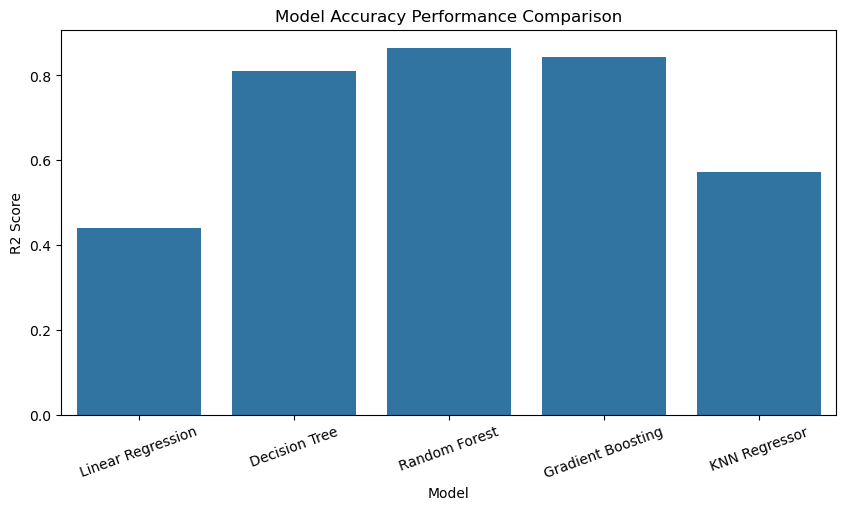

In [50]:
plt.figure(figsize=(10,5))
sns.barplot(x='Model', y='R2 Score', data=results)
plt.xticks(rotation=20)
plt.title('Model Accuracy Performance Comparison')
plt.show()

In [29]:
best_model = results.loc[results['R2 Score'].idxmax()]

print(best_model)

Model       Random Forest
R2 Score         0.864875
Name: 2, dtype: object


## Step 13: Hyperparameter Tuning - Random Forest

In [31]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

params = {
    'n_estimators': [100, 200],
    'max_depth': [10, 15],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(
    RandomForestRegressor(),
    params,
    cv=3
)

grid.fit(X_train, y_train)

print(grid.best_params_)

{'max_depth': 15, 'min_samples_split': 2, 'n_estimators': 100}


In [32]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)

In [33]:
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [34]:
rf_pred = rf_model.predict(X_test)

In [35]:
from sklearn.metrics import r2_score

accuracy = r2_score(y_test, rf_pred)

print("R2 Score:", accuracy)

R2 Score: 0.8447564293987946


In [36]:
from sklearn.model_selection import train_test_split

X = df.drop('Price', axis=1)
y = df['Price']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [37]:
rf_model.fit(X_train, y_train)

predictions = rf_model.predict(X_test)

In [38]:
comparison = pd.DataFrame({
    'Actual Price': y_test,
    'Predicted Price': predictions
})

print(comparison.head())

      Actual Price  Predicted Price
6075         16655     16546.955974
3544          4959      5445.574786
9290          9187      8922.034569
5032          3858      4062.910337
2483         12898     12609.280624


In [39]:
new_data = [[
    3,   # Airline
    1,   # Source
    2,   # Destination
    5,   # Route
    26,  #Journey_year
    15,  # Journey_Day
    6,   # Journey_Month
    2,   # Weekday
    10,  # Dep_Hour
    30,  # Dep_Minute
    14,  # Arr_Hour
    45,  # Arr_Minute
    240, # Duration_Mins
    1,   # Total_Stops
    0    # Additional_Info
]]

In [40]:
predicted_price = rf_model.predict(new_data)

print("Predicted Flight Price:", predicted_price)

Predicted Flight Price: [7202.80126828]


# Phase 2: Pipeline Integration
## step 1: Define Feature Groups

In [41]:
num_features = [
    'Duration_Mins',
    'Journey_Day',
    'Journey_Month'
]

cat_features = [
    'Airline',
    'Source',
    'Destination',
    'Total_Stops'
]

## Step 2: Create Preprocessing Pipeline

In [42]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
    ]
)

## Step 3: Build Final End-to-End Pipeline

* Since Random Forest Regressor is your best model:

In [43]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

final_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ))
])

## Step 4: Train Pipeline

#### Train directly on raw data:

In [44]:
final_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


* No manual encoding or scaling is required because the pipeline handles everything automatically.

## Step 5: Export Pipeline

In [45]:
import joblib

joblib.dump(
    final_pipeline,
    'flight_price_pipeline.pkl'
)

print("Pipeline Saved Successfully")

Pipeline Saved Successfully


In [46]:
new_data = [[
    3,   # Airline
    1,   # Source
    2,   # Destination
    5,   # Route
    26,  #Journey_year
    15,  # Journey_Day
    6,   # Journey_Month
    2,   # Weekday
    10,  # Dep_Hour
    30,  # Dep_Minute
    14,  # Arr_Hour
    45,  # Arr_Minute
    240, # Duration_Mins
    1,   # Total_Stops
    0    # Additional_Info
]]

In [47]:
predicted_price = rf_model.predict(new_data)

print("Predicted Flight Price:", predicted_price)

Predicted Flight Price: [7202.80126828]


In [48]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

pipeline = Pipeline([
    ('model', RandomForestRegressor())
])

pipeline.fit(X_train, y_train)

prediction = pipeline.predict(new_data)
print("Predicted Flight Price:", prediction)

Predicted Flight Price: [7144.05]


In [49]:
import joblib

joblib.dump(final_pipeline, "flight_price_pipeline.pkl")

['flight_price_pipeline.pkl']

## Project Conclusion

##### This project successfully developed a Flight Ticket Price Prediction System using Machine Learning techniques. The dataset was preprocessed through data cleaning, feature engineering, and exploratory data analysis (EDA) to identify important factors affecting ticket prices. Five regression algorithms—Linear Regression, Decision Tree Regressor, Random Forest Regressor, Gradient Boosting Regressor, and K-Nearest Neighbors (KNN) Regressor—were implemented and evaluated using performance metrics such as R² Score, MAE, and RMSE.

##### Among all models, the Random Forest Regressor achieved the highest prediction accuracy and was selected as the final model. The preprocessing steps and trained model were integrated into a single automated pipeline and saved for deployment. To make the solution user-friendly and accessible, a Streamlit web application was developed, allowing users to input flight details and receive real-time ticket price predictions.

##### Overall, this project demonstrates the complete machine learning lifecycle, including data preprocessing, model development, evaluation, deployment, and user interaction. The solution can assist travelers, travel agencies, and booking platforms in estimating flight prices efficiently and making informed decisions.